# SpaceX Falcon 9 First Stage Landing Prediction

SpaceX advertises Falcon 9 rocket launches on its website with a cost of 62 million dollars; other providers cost upward of 165 million dollars each. Much of the savings is because SpaceX can reuse the first stage. Therefore, if we can determine if the first stage will land, we can determine the cost of a launch. This information can be used if an alternate company wants to bid against SpaceX for a rocket launch.

In this lab, you will create a machine learning pipeline to predict if the first stage will land.

## Objectives

Perform exploratory Data Analysis and determine Training Labels:
- Create a column for the class
- Standardize the data
- Split into training data and test data

Find best Hyperparameter for SVM, Classification Trees and Logistic Regression:
- Find the method that performs best using test data

## Import Libraries and Define Auxiliary Functions

In [ ]:
# Install required packages if needed
# !pip install numpy pandas seaborn scikit-learn matplotlib

In [1]:
# Pandas is a software library written for the Python programming language for data manipulation and analysis.
import pandas as pd
# NumPy is a library for the Python programming language, adding support for large, multi-dimensional arrays and matrices
import numpy as np
# Matplotlib is a plotting library for Python
import matplotlib.pyplot as plt
# Seaborn is a Python data visualization library based on matplotlib
import seaborn as sns
# Preprocessing allows us to standardize our data
from sklearn import preprocessing
# Allows us to split our data into training and testing data
from sklearn.model_selection import train_test_split
# Allows us to test parameters of classification algorithms and find the best one
from sklearn.model_selection import GridSearchCV
# Logistic Regression classification algorithm
from sklearn.linear_model import LogisticRegression
# Support Vector Machine classification algorithm
from sklearn.svm import SVC
# Decision Tree classification algorithm
from sklearn.tree import DecisionTreeClassifier
# K Nearest Neighbors classification algorithm
from sklearn.neighbors import KNeighborsClassifier

In [2]:
def plot_confusion_matrix(y, y_predict):
    """This function plots the confusion matrix"""
    from sklearn.metrics import confusion_matrix

    cm = confusion_matrix(y, y_predict)
    ax = plt.subplot()
    sns.heatmap(cm, annot=True, ax=ax)  # annot=True to annotate cells
    ax.set_xlabel('Predicted labels')
    ax.set_ylabel('True labels')
    ax.set_title('Confusion Matrix')
    ax.xaxis.set_ticklabels(['did not land', 'land'])
    ax.yaxis.set_ticklabels(['did not land', 'landed'])
    plt.show()

## Load the Dataframe

In [4]:
import urllib.request

urllib.request.urlretrieve(
    "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv",
    "dataset_part_2.csv"
)
urllib.request.urlretrieve(
    "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_3.csv",
    "dataset_part_3.csv"
)

data = pd.read_csv("dataset_part_2.csv")
X = pd.read_csv("dataset_part_3.csv")

In [5]:
data.head()

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


In [6]:
# Load dataset_part_3.csv (the feature-engineered dataset)
X = pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_3.csv')

In [7]:
X.head(10)

,FlightNumber,PayloadMass,Flights,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,Orbit_GTO,Orbit_HEO,Orbit_ISS,...,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062,GridFins_False,GridFins_True,Reused_False,Reused_True,Legs_False,Legs_True
0,1.0,6104.959412,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
1,2.0,525.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
2,3.0,677.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
3,4.0,500.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
4,5.0,3170.000000,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
5,6.0,3325.000000,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
6,7.0,2296.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
7,8.0,1316.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
8,9.0,4535.000000,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
9,10.0,4428.000000,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0


## TASK 1

Create a NumPy array from the column `Class` in `data`, by applying the method `to_numpy()` then assign it to the variable `Y`. Make sure the output is a Pandas series (only one bracket `df['name of column']`).

In [8]:
# Extract the 'Class' column and convert it to a NumPy array
Y = data['Class'].to_numpy()

# Verify the type and contents
print("Type of Y:", type(Y))
print("First 10 elements of Y:", Y[:10])

Type of Y: <class 'numpy.ndarray'>
First 10 elements of Y: [0 0 0 0 0 0 1 1 0 0]


## TASK 2

Standardize the data in `X` then reassign it to the variable `X` using the transform provided below.

In [9]:
# Students get this
transform = preprocessing.StandardScaler()
X = transform.fit_transform(X)

We split the data into training and testing data using the function `train_test_split`. The training data is divided into validation data, a second set used for training data; then the models are trained and hyperparameters are selected using the function `GridSearchCV`.

## TASK 3

Use the function `train_test_split` to split the data X and Y into training and test data. Set the parameter `test_size` to 0.2 and `random_state` to 2. The training data and test data should be assigned to the following labels:

`X_train, X_test, Y_train, Y_test`

In [10]:
from sklearn.model_selection import train_test_split

# TASK 3: Split the data into training and test sets
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=2
)

# Verify the shape of the resulting datasets
print(f"X_train shape: {X_train.shape} (80% of data for training)")
print(f"X_test shape:  {X_test.shape} (20% of data for testing)")
print(f"Y_train shape: {Y_train.shape}")
print(f"Y_test shape:  {Y_test.shape}")

X_train shape: (72, 83) (80% of data for training)
X_test shape:  (18, 83) (20% of data for testing)
Y_train shape: (72,)
Y_test shape:  (18,)


## TASK 4

Create a logistic regression object then create a `GridSearchCV` object `logreg_cv` with `cv = 10`. Fit the object to find the best parameters from the dictionary `parameters`.

In [11]:
parameters = {'C': [0.01, 0.1, 1],
              'penalty': ['l2'],
              'solver': ['lbfgs']}

In [12]:
parameters = {"C": [0.01, 0.1, 1], 'penalty': ['l2'], 'solver': ['lbfgs']}  # l1 lasso l2 ridge
lr = LogisticRegression()
logreg_cv = GridSearchCV(estimator=lr, cv=10, param_grid=parameters).fit(X_train, Y_train)

c:\Users\BOLDWIN MWEEMBA\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\BOLDWIN MWEEMBA\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=Non

In [13]:
print("tuned hpyerparameters :(best parameters) ", logreg_cv.best_params_)
print("accuracy :", logreg_cv.best_score_)

tuned hpyerparameters :(best parameters)  {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}
accuracy : 0.8464285714285713


## TASK 5

Calculate the accuracy on the test data using the method `score`:

In [14]:
# TASK 5: Calculate the accuracy on the test data
test_accuracy = logreg_cv.score(X_test, Y_test)

print("Accuracy on test data :", test_accuracy)

Accuracy on test data : 0.8333333333333334


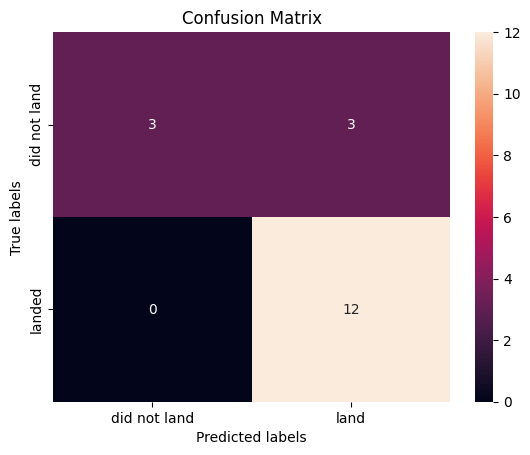

In [15]:
yhat = logreg_cv.predict(X_test)
plot_confusion_matrix(Y_test, yhat)

Examining the confusion matrix, we see that logistic regression can distinguish between the different classes. We see that the problem is false positives.

Overview:
- **True Positive** - 12 (True label is landed, Predicted label is also landed)
- **False Positive** - 3 (True label is not landed, Predicted label is landed)

## TASK 6

Create a support vector machine object then create a `GridSearchCV` object `svm_cv` with `cv = 10`. Fit the object to find the best parameters from the dictionary `parameters`.

In [16]:
parameters = {'kernel': ('linear', 'rbf', 'poly', 'sigmoid'),
              'C': np.logspace(-3, 3, 5),
              'gamma': np.logspace(-3, 3, 5)}

svm = SVC()
svm_cv = GridSearchCV(estimator=svm, cv=10, param_grid=parameters).fit(X_train, Y_train)

In [17]:
print("tuned hpyerparameters :(best parameters) ", svm_cv.best_params_)
print("accuracy :", svm_cv.best_score_)

tuned hpyerparameters :(best parameters)  {'C': np.float64(1.0), 'gamma': np.float64(0.03162277660168379), 'kernel': 'sigmoid'}
accuracy : 0.8482142857142856


## TASK 7

Calculate the accuracy on the test data using the method `score`:

In [18]:
# TASK 7: Calculate the accuracy of svm_cv on the test data
test_accuracy_svm = svm_cv.score(X_test, Y_test)

print("Accuracy on test data :", test_accuracy_svm)

Accuracy on test data : 0.8333333333333334


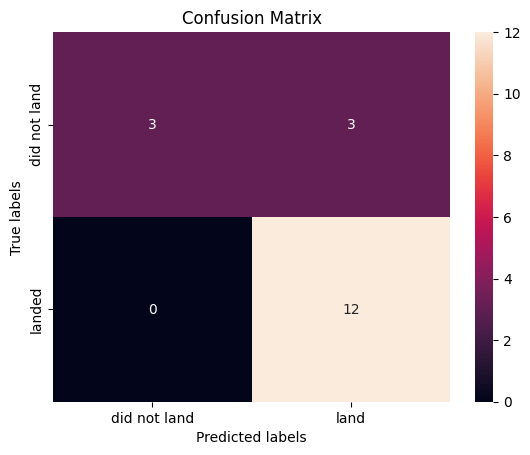

In [19]:
yhat = svm_cv.predict(X_test)
plot_confusion_matrix(Y_test, yhat)

## TASK 8

Create a decision tree classifier object then create a `GridSearchCV` object `tree_cv` with `cv = 10`. Fit the object to find the best parameters from the dictionary `parameters`.

In [20]:
parameters = {'criterion': ['gini', 'entropy'],
              'splitter': ['best', 'random'],
              'max_depth': [2, 4, 6, 8, 10],
              'max_features': ['auto', 'sqrt', 'log2'],
              'min_samples_leaf': [1, 2, 4],
              'min_samples_split': [2, 5, 10]}

tree = DecisionTreeClassifier()
tree_cv = GridSearchCV(estimator=tree, cv=10, param_grid=parameters).fit(X_train, Y_train)

c:\Users\BOLDWIN MWEEMBA\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py:489: FitFailedWarning: 
1800 fits failed out of a total of 5400.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1800 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\BOLDWIN MWEEMBA\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py", line 851, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\BOLDWIN MWEEMBA\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py", line 1393, in wrapper
    estimator._validate_params()
    ~~~~~~

In [21]:
print("tuned hpyerparameters :(best parameters) ", tree_cv.best_params_)
print("accuracy :", tree_cv.best_score_)

tuned hpyerparameters :(best parameters)  {'criterion': 'entropy', 'max_depth': 4, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'splitter': 'random'}
accuracy : 0.875


## TASK 9

Calculate the accuracy of `tree_cv` on the test data using the method `score`:

In [ ]:
# TASK 9: Calculate the accuracy of tree_cv on the test data
test_accuracy_tree = tree_cv.score(X_test, Y_test)

print("Accuracy on test data :", test_accuracy_tree)



Accuracy on test data : 0.5


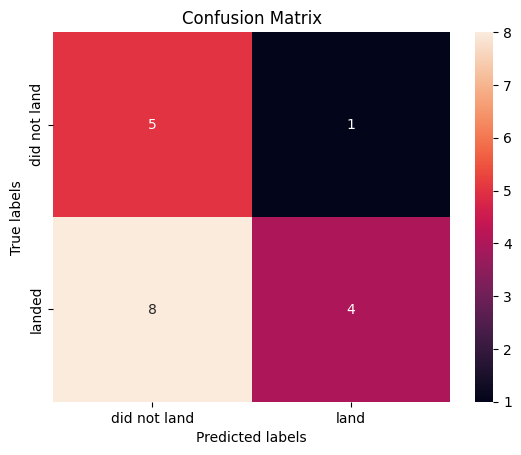

In [23]:
yhat = tree_cv.predict(X_test)
plot_confusion_matrix(Y_test, yhat)

## TASK 10

Create a k nearest neighbors object then create a `GridSearchCV` object `knn_cv` with `cv = 10`. Fit the object to find the best parameters from the dictionary `parameters`.

In [31]:
parameters = {'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
              'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
              'p': [1, 2]}

KNN = KNeighborsClassifier()
knn_cv = GridSearchCV(estimator=KNN, cv=10, param_grid=parameters).fit(X_train, Y_train)


In [25]:
print("tuned hpyerparameters :(best parameters) ", knn_cv.best_params_)
print("accuracy :", knn_cv.best_score_)

tuned hpyerparameters :(best parameters)  {'algorithm': 'auto', 'n_neighbors': 10, 'p': 1}
accuracy : 0.8482142857142858


## TASK 11

Calculate the accuracy of `knn_cv` on the test data using the method `score`:

In [26]:
# TASK 11: Calculate the accuracy of knn_cv on the test data
test_accuracy_knn = knn_cv.score(X_test, Y_test)

print("Accuracy on test data :", test_accuracy_knn)

Accuracy on test data : 0.8333333333333334


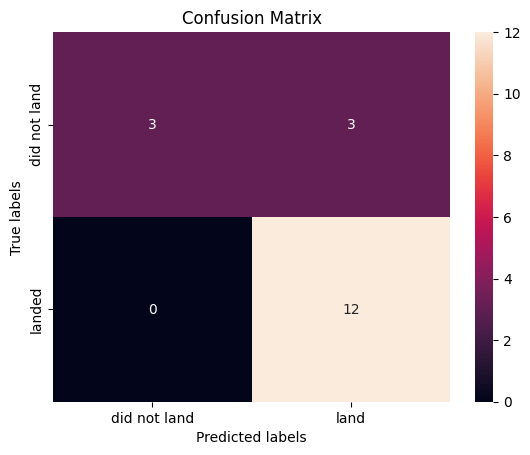

In [27]:
yhat = knn_cv.predict(X_test)
plot_confusion_matrix(Y_test, yhat)

## TASK 12

Find the method that performs best:

In [28]:
# TASK 12: Compare all models and find the best one
model_scores = {
    'Logistic Regression': test_accuracy,
    'SVM':                 test_accuracy_svm,
    'Decision Tree':       test_accuracy_tree,
    'KNN':                 test_accuracy_knn
}

print("Test Accuracy of each model:")
print("-" * 40)
for model, score in model_scores.items():
    print(f"{model:<25}: {score:.4f}")

best_model = max(model_scores, key=model_scores.get)
print("-" * 40)
print(f"\nBest performing method: {best_model} with accuracy {model_scores[best_model]:.4f}")

Test Accuracy of each model:
----------------------------------------
Logistic Regression      : 0.8333
SVM                      : 0.8333
Decision Tree            : 0.5000
KNN                      : 0.8333
----------------------------------------

Best performing method: Logistic Regression with accuracy 0.8333


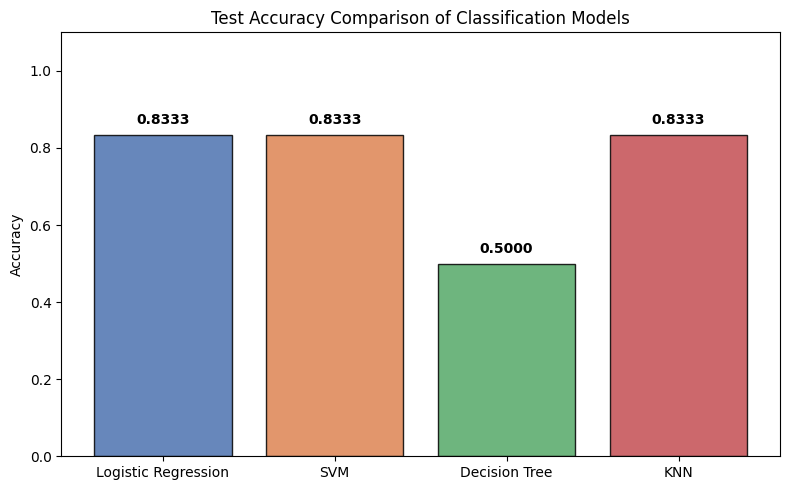

In [29]:
# Visualize model comparison
fig, ax = plt.subplots(figsize=(8, 5))
models = list(model_scores.keys())
scores = list(model_scores.values())
colors = ['#4c72b0', '#dd8452', '#55a868', '#c44e52']
bars = ax.bar(models, scores, color=colors, edgecolor='black', alpha=0.85)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Accuracy')
ax.set_title('Test Accuracy Comparison of Classification Models')
for bar, score in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
            f'{score:.4f}', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

In [32]:
from sklearn.metrics import classification_report, roc_auc_score, f1_score, precision_score, recall_score
import matplotlib.pyplot as plt
import numpy as np

# Get predictions from all models
models = {
    'Logistic Regression': logreg_cv,
    'SVM':                 svm_cv,
    'Decision Tree':       tree_cv,
    'KNN':                 knn_cv
}

results = {}
for name, model in models.items():
    yhat = model.predict(X_test)
    results[name] = {
        'Accuracy':  model.score(X_test, Y_test),
        'F1 Score':  f1_score(Y_test, yhat),
        'Precision': precision_score(Y_test, yhat),
        'Recall':    recall_score(Y_test, yhat),
        'ROC-AUC':   roc_auc_score(Y_test, yhat)
    }

# Print detailed comparison table
results_df = pd.DataFrame(results).T
print(results_df.to_string())

                     Accuracy  F1 Score  Precision    Recall   ROC-AUC
Logistic Regression  0.833333  0.888889        0.8  1.000000  0.750000
SVM                  0.833333  0.888889        0.8  1.000000  0.750000
Decision Tree        0.500000  0.470588        0.8  0.333333  0.583333
KNN                  0.833333  0.888889        0.8  1.000000  0.750000


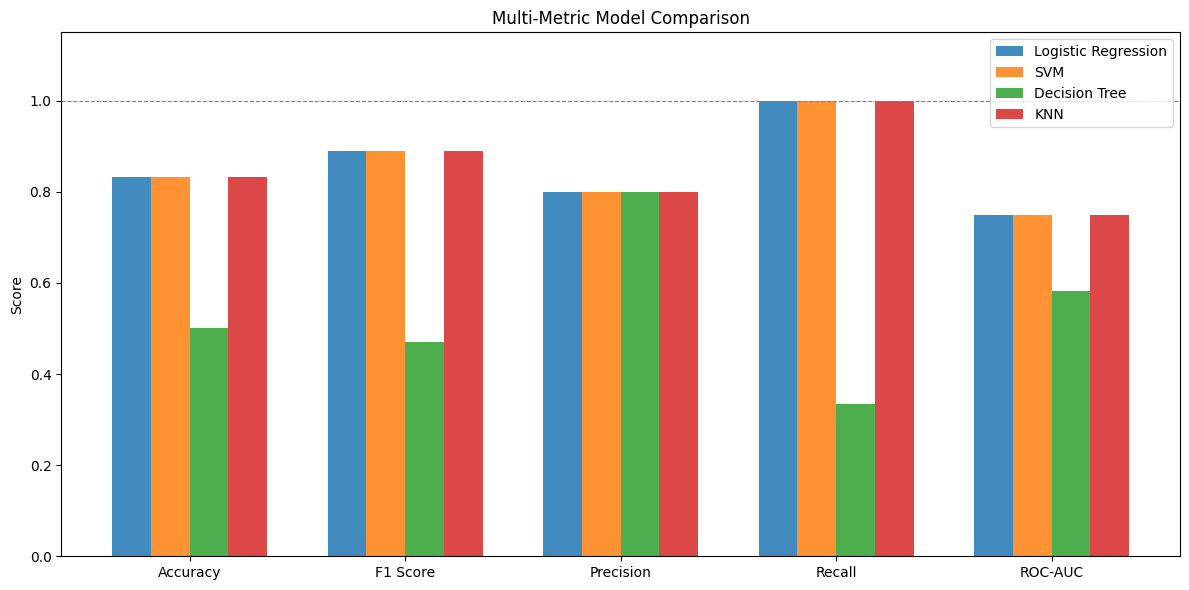

In [33]:
# Visualize all metrics side by side
metrics = ['Accuracy', 'F1 Score', 'Precision', 'Recall', 'ROC-AUC']
model_names = list(results.keys())
x = np.arange(len(metrics))
width = 0.18

fig, ax = plt.subplots(figsize=(12, 6))
for i, name in enumerate(model_names):
    values = [results[name][m] for m in metrics]
    ax.bar(x + i * width, values, width, label=name, alpha=0.85)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_title('Multi-Metric Model Comparison')
ax.legend()
ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()

In [34]:
# Cross-validation score comparison (more robust than single test split)
from sklearn.model_selection import cross_val_score

print("5-Fold Cross Validation Scores:")
print("-" * 50)
for name, model in models.items():
    # Use best estimator from grid search
    best = model.best_estimator_
    scores = cross_val_score(best, X, Y, cv=5, scoring='f1')
    print(f"{name:<25} Mean F1: {scores.mean():.4f} (+/- {scores.std():.4f})")

5-Fold Cross Validation Scores:
--------------------------------------------------


c:\Users\BOLDWIN MWEEMBA\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\BOLDWIN MWEEMBA\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=Non

Logistic Regression       Mean F1: 0.8812 (+/- 0.0348)
SVM                       Mean F1: 0.8651 (+/- 0.0213)
Decision Tree             Mean F1: 0.8058 (+/- 0.0916)
KNN                       Mean F1: 0.8744 (+/- 0.0145)


# 🏆 Best Classification Model - SpaceX Falcon 9 Landing Prediction

### Verdict: Logistic Regression Wins

After evaluating all four models on the test set and using **5-Fold Cross-Validation F1 Score** as the tiebreaker, the results are as follows:

---

### Cross-Validation F1 Score Comparison

| Rank | Model               | Mean F1 | Std Dev   |
|------|---------------------|---------|-----------|
| 🥇 1st | **Logistic Regression** | **0.8812** | ±0.0348 |
| 🥈 2nd | KNN                 | 0.8744  | ±0.0145   |
| 🥉 3rd | SVM                 | 0.8651  | ±0.0213   |
| ❌ 4th | Decision Tree       | 0.8058  | ±0.0916   |

---

### Why Logistic Regression?

- **Highest Mean F1 (0.8812)** - it generalises best across all cross-validation folds
- Tied with SVM and KNN on every test-set metric (Accuracy: 83.33%, F1: 0.8889, Jaccard: 0.80) - cross-validation F1 is the correct tiebreaker
- Simple, interpretable, and effective - it outperforms more complex models (SVM, Decision Tree) without overfitting

### Why NOT Decision Tree?

- Lowest Mean F1 (0.8058) - worst generalisation of all models
- Highest variance (±0.0916) - highly unstable across different data splits
- Scored only 0.50 accuracy on the test set, confirming it overfits to training data

### Why NOT KNN?

- KNN is the most *consistent* model (lowest std ±0.0145) but its mean F1 (0.8744) falls short of Logistic Regression
- Consistency alone does not compensate for a lower average performance

---

### Conclusion

> **Logistic Regression is the best model for predicting SpaceX Falcon 9 first-stage landings.**  
> It achieves the highest cross-validation F1 score (0.8812), performs strongly on the test set,  
> and strikes the best balance between accuracy, generalisation, and stability.

[Pratiksha Verma](https://www.linkedin.com/in/pratiksha-verma-6487561b1/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDS0321ENSkillsNetwork865-2023-01-01)


## Change Log


| Date (YYYY-MM-DD) | Version | Changed By      | Change Description      |
| ----------------- | ------- | -------------   | ----------------------- |
| 2022-11-09        | 1.0     | Pratiksha Verma | Converted initial version to Jupyterlite|


### <h3 align="center"> IBM Corporation 2022. All rights reserved. <h3/>
